In [37]:
import numpy as np

class Softmax:
    # Xavier initialization
    weight_init_factor = 1.

    def forward(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

class Sigmoid:
    # Xavier initialization
    weight_init_factor = 1.

    def forward(self, x):
        return 1 / (1 + np.exp(-x))
    
    def derivative(self, x):
        s = self.forward(x)
        return s * (1 - s)


class ReLU:
    # He initialization
    weight_init_factor = np.sqrt(2)

    def forward(self, x):
        return np.maximum(0, x)
    
    def derivative(self, x):
        return (x > 0).astype(float)

In [38]:
class Layer:
    def __init__(self, num_neurons: int, num_input_connections: int, activation_function, rng, alpha=0.05, beta_one=0.9, beta_two=0.999, epsilon = 1e-8):
        self.num_neurons = num_neurons
        self.activation_function = activation_function
        self.weights =  rng.standard_normal((num_input_connections, num_neurons)) * activation_function.weight_init_factor * np.sqrt(1/num_input_connections)
        self.biases = self.biases = rng.standard_normal(num_neurons) * 0.01
        self.prev_inputs = None
        self.z = None
        self.error_signals = None
        self.alpha = alpha


        # adam optimizer stuff
        self.ma_weight_signal = np.zeros((num_input_connections, num_neurons)) # moving average bias gradient signal for adam optimizer
        self.ma_bias_signal = np.zeros(num_neurons) # moving average weight gradient signal for adam optimizer
        self.update_steps = 0
        self.beta_one = beta_one
        self.ma_weight_signal_variance = np.zeros((num_input_connections, num_neurons))
        self.ma_bias_signal_variance = np.zeros(num_neurons)
        self.beta_two = beta_two
        self.epsilon = epsilon

    def forward(self, x) -> np.array:
        self.z = x @ self.weights + self.biases
        self.prev_inputs = x
        return self.activation_function.forward(self.z)

    def backward(self, error_signals) -> np.array:
        self.update_steps += 1

        # i didnt add a derivative to softmax cus im lazy, i didn't feel like spending the time figuring out the jacobians, just passing the loss for the next step all the way through
        if hasattr(self.activation_function, 'derivative'):
            dLdz = error_signals * self.activation_function.derivative(self.z)
        else:
            dLdz = error_signals
    
        batch_size = error_signals.shape[0]

        bias_gradient_signal = np.sum(dLdz, axis=0) / batch_size
        self.ma_bias_signal = (self.beta_one * self.ma_bias_signal) + (1 - self.beta_one) * bias_gradient_signal # first moment
        self.ma_bias_signal_variance = (self.beta_two * self.ma_bias_signal_variance) + (1 - self.beta_two) * bias_gradient_signal ** 2
        mb = self.ma_bias_signal / (1 - self.beta_one ** self.update_steps)
        vb = self.ma_bias_signal_variance / (1 - self.beta_two ** self.update_steps)
        dB = mb / (np.sqrt(vb) + self.epsilon)

        weight_gradient_signal = (self.prev_inputs.T @ dLdz) / batch_size
        self.ma_weight_signal = ( (self.beta_one * self.ma_weight_signal) + (1 - self.beta_one) * weight_gradient_signal ) # first moment
        self.ma_weight_signal_variance = (self.beta_two * self.ma_weight_signal_variance) + (1 - self.beta_two) * weight_gradient_signal ** 2
        mw = self.ma_weight_signal / (1 - self.beta_one ** self.update_steps)
        vw = self.ma_weight_signal_variance / (1 - self.beta_two ** self.update_steps)
        dW = mw / (np.sqrt(vw) + self.epsilon)

        error_signals = dLdz @ self.weights.T
        self.biases += -self.alpha * dB
        self.weights += -self.alpha * dW

        # print(error_signals)
        return error_signals

x = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0, 1],
    [1, 0],
    [1, 0],
    [0, 1]
])


0.738475844190692
0.4773861860005708
0.47738588441464513
0.47738575573307246
0.47738564032672465
0.4773856387174109
0.47738563677924034
0.4773856345598781
0.4773856324125356
0.47738563052535377


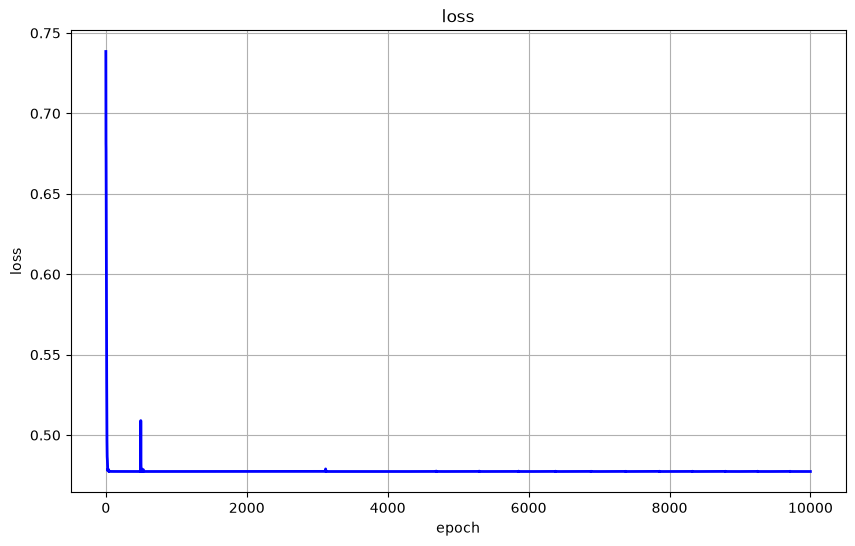

In [ ]:
rng = np.random.default_rng(42)
layers = [
    Layer(num_neurons=4, num_input_connections=2, activation_function=ReLU(), rng=rng, alpha=0.005),
    Layer(num_neurons=2, num_input_connections=4, activation_function=Softmax(), rng=rng, alpha=0.005)
]

import matplotlib.pyplot as plt
loss_history = []
for i in range(10000):
    out = x
    for layer in layers:
        out = layer.forward(out)

    eps = 1e-15
    out = np.clip(out, eps, 1 - eps)
    loss = -np.sum(y * np.log(out)) / x.shape[0]
    loss_history.append(loss)

    if i % 1000 == 0:
        print(loss)

    upstream_error = out - y
    for layer in reversed(layers):
        upstream_error = layer.backward(upstream_error)

plt.figure(figsize=(10,6))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)
plt.show()


In [40]:
out = x
for layer in layers:
    out = layer.forward(out)
print(out)


[[3.33333337e-01 6.66666663e-01]
 [3.33333337e-01 6.66666663e-01]
 [9.99999989e-01 1.14618982e-08]
 [3.33333337e-01 6.66666663e-01]]
